**Setup and Download Dataset**

In [1]:
# install libraries
!pip install -q kaggle seaborn matplotlib plotly scikit-learn shap imbalanced-learn xgboost tensorflow

# import libraries
import os
import json
from pathlib import Path
import pandas as pd

# kaggle api setup
kaggle_token = {
"username": "your_kaggle_username",
"key": "your_kaggle_api_key"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_token, f)

os.chmod("/root/.kaggle/kaggle.json", 0o600)

# download dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud

# unzip dataset
!unzip -q creditcardfraud.zip -d fraud_data

# load dataset
DATA_DIR = Path("fraud_data")
files = list(DATA_DIR.rglob("*.csv"))

df = pd.read_csv(files[0])

# preview
df.head()

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 200MB/s]



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Data Understanding & Structure Analysis**

In [2]:
# show all columns
print("columns:\n", df.columns.tolist())

# show first rows
print("\nhead:\n", df.head())

# show last rows
print("\ntail:\n", df.tail())

# dataset shape
print("\nshape:", df.shape)

# data types
print("\ndtypes:\n", df.dtypes)

# missing values
print("\nmissing values:\n", df.isnull().sum())

# duplicate rows
print("\nduplicates:", df.duplicated().sum())

# unique values count for each column
print("\nunique values per column:\n", df.nunique())

# check unique values for target
print("\nunique values in class:\n", df["Class"].unique())

# value counts for target
print("\nclass distribution:\n", df["Class"].value_counts())

# percentage distribution
print("\nclass percentage:\n", df["Class"].value_counts(normalize=True) * 100)

columns:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

head:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.

In [3]:
for col in df.columns:
    print("\ncolumn:", col)
    print(df[col].unique()[:10])


column: Time
[ 0.  1.  2.  4.  7.  9. 10. 11. 12. 13.]

column: V1
[-1.35980713  1.19185711 -1.35835406 -0.96627171 -1.15823309 -0.42596588
  1.22965763 -0.64426944 -0.89428608 -0.33826175]

column: V2
[-0.07278117  0.26615071 -1.34016307 -0.18522601  0.87773675  0.96052304
  0.14100351  1.41796355  0.2861572   1.11959338]

column: V3
[ 2.53634674  0.16648011  1.77320934  1.79299334  1.54871785  1.14110934
  0.04537077  1.07438038 -0.11319221  1.04436655]

column: V4
[ 1.37815522  0.44815408  0.37977959 -0.86329128  0.40303393 -0.16825208
  1.20261274 -0.49219902 -0.27152613 -0.22218728]

column: V5
[-0.33832077  0.06001765 -0.50319813 -0.01030888 -0.40719338  0.42098688
  0.19188099  0.94893409  2.66959866  0.49936081]

column: V6
[ 0.46238778 -0.08236081  1.80049938  1.24720317  0.09592146 -0.02972755
  0.27270812  0.42811846  3.72181806 -0.2467611 ]

column: V7
[ 0.23959855 -0.07880298  0.79146096  0.23760894  0.59294075  0.47620095
 -0.005159    1.12063136  0.37014513  0.65158321]

**DATA CLEANING & PREPROCESSING**

In [4]:
# copy dataset
data = df.copy()

# check missing values
print("missing values:\n", data.isnull().sum())

# remove duplicates
data = data.drop_duplicates()

print("\nafter removing duplicates:", data.shape)

# separate features and target
X = data.drop("Class", axis=1)
y = data["Class"]

# normalize amount and time
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"] = scaler.fit_transform(X[["Time"]])

print("\nscaled columns done")

# check class imbalance
print("\nclass distribution before:\n", y.value_counts())

missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

after removing duplicates: (283726, 31)

scaled columns done

class distribution before:
 Class
0    283253
1       473
Name: count, dtype: int64


**SMOTE (Imbalance Handling)**

In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# apply smote
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nclass distribution after smote:\n", y_train_res.value_counts())


class distribution after smote:
 Class
0    226602
1    226602
Name: count, dtype: int64


**Exploratory Data Analysis**

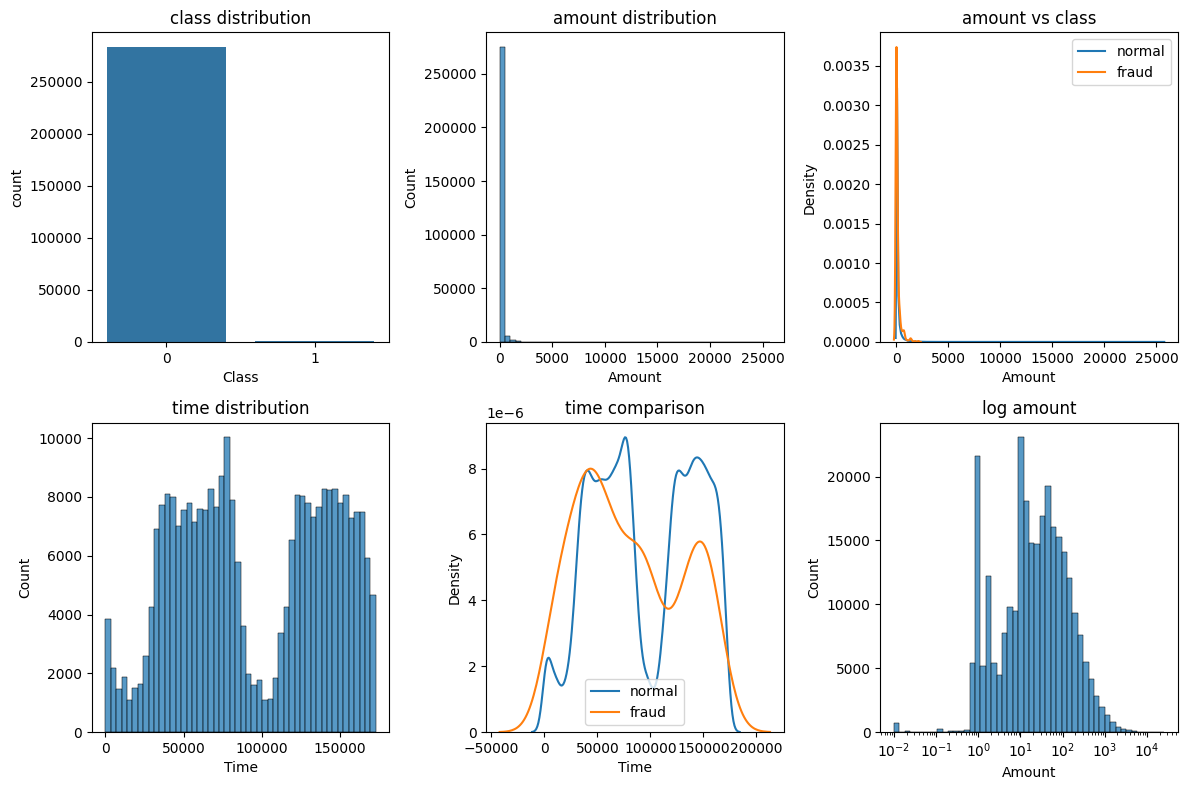

In [7]:
# import libraries
import matplotlib.pyplot as plt
import seaborn as sns

# create figure
plt.figure(figsize=(12,8))

# class distribution
plt.subplot(2,3,1)
sns.countplot(x=data["Class"])
plt.title("class distribution")

# amount distribution
plt.subplot(2,3,2)
sns.histplot(data["Amount"], bins=50)
plt.title("amount distribution")

# amount vs class using kde
plt.subplot(2,3,3)
sns.kdeplot(data[data["Class"]==0]["Amount"], label="normal")
sns.kdeplot(data[data["Class"]==1]["Amount"], label="fraud")
plt.legend()
plt.title("amount vs class")

# time distribution
plt.subplot(2,3,4)
sns.histplot(data["Time"], bins=50)
plt.title("time distribution")

# time comparison
plt.subplot(2,3,5)
sns.kdeplot(data[data["Class"]==0]["Time"], label="normal")
sns.kdeplot(data[data["Class"]==1]["Time"], label="fraud")
plt.legend()
plt.title("time comparison")

# amount log distribution
plt.subplot(2,3,6)
sns.histplot(data["Amount"], bins=50, log_scale=True)
plt.title("log amount")

# layout and show
plt.tight_layout()
plt.show()

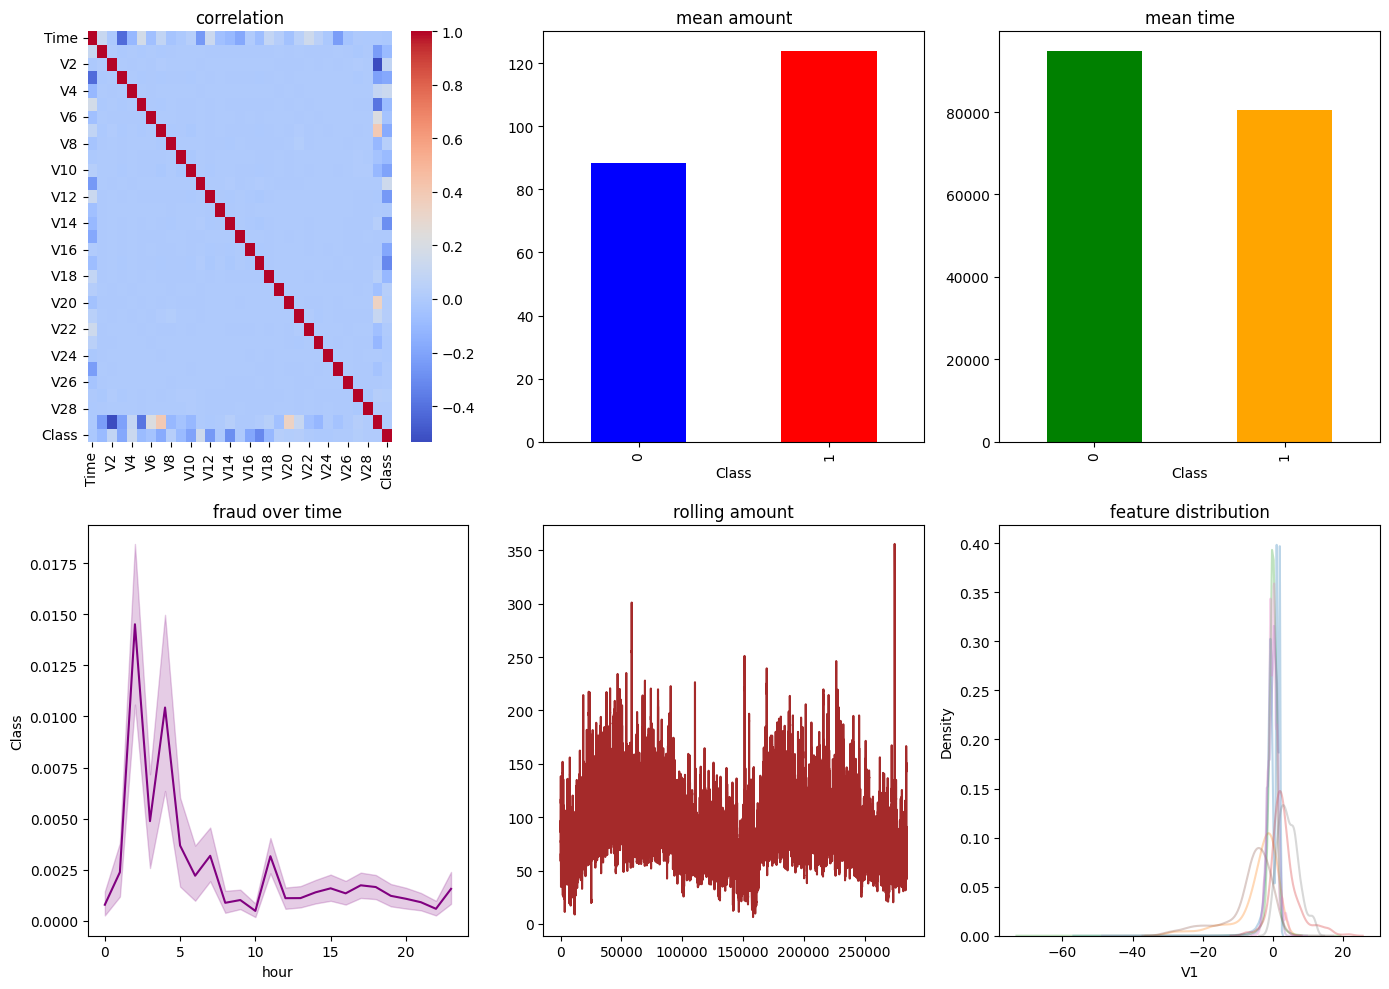

In [8]:
# create figure
plt.figure(figsize=(14,10))

# correlation heatmap
plt.subplot(2,3,1)
corr = data.corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("correlation")

# mean amount by class
plt.subplot(2,3,2)
data.groupby("Class")["Amount"].mean().plot(kind="bar", color=["blue","red"])
plt.title("mean amount")

# mean time by class
plt.subplot(2,3,3)
data.groupby("Class")["Time"].mean().plot(kind="bar", color=["green","orange"])
plt.title("mean time")

# fraud over time
plt.subplot(2,3,4)
data["hour"] = (data["Time"] // 3600) % 24
sns.lineplot(x="hour", y="Class", data=data, estimator="mean", color="purple")
plt.title("fraud over time")

# rolling transaction pattern
plt.subplot(2,3,5)
data["rolling_amount"] = data["Amount"].rolling(100).mean()
plt.plot(data["rolling_amount"], color="brown")
plt.title("rolling amount")

# feature distribution comparison
plt.subplot(2,3,6)
features = ["V1","V2","V3","V4"]
for f in features:
    sns.kdeplot(data[data["Class"]==0][f], alpha=0.3)
    sns.kdeplot(data[data["Class"]==1][f], alpha=0.3)
plt.title("feature distribution")

# layout and show
plt.tight_layout()
plt.show()

**Feature Engineering**

In [9]:
# sort data by time
data = data.sort_values(by="Time").reset_index(drop=True)

# time difference between transactions
data["time_diff"] = data["Time"].diff().fillna(0)

# rolling transaction count
data["tx_count_10"] = data["Class"].rolling(window=10).count()
data["tx_count_50"] = data["Class"].rolling(window=50).count()

# rolling amount features
data["amt_mean_10"] = data["Amount"].rolling(window=10).mean()
data["amt_std_10"] = data["Amount"].rolling(window=10).std()

data["amt_mean_50"] = data["Amount"].rolling(window=50).mean()
data["amt_std_50"] = data["Amount"].rolling(window=50).std()

# fill missing values
data = data.fillna(0)

# prepare final dataset
X = data.drop("Class", axis=1)
y = data["Class"]

# check shape
print("final features:", X.shape)

final features: (283726, 39)


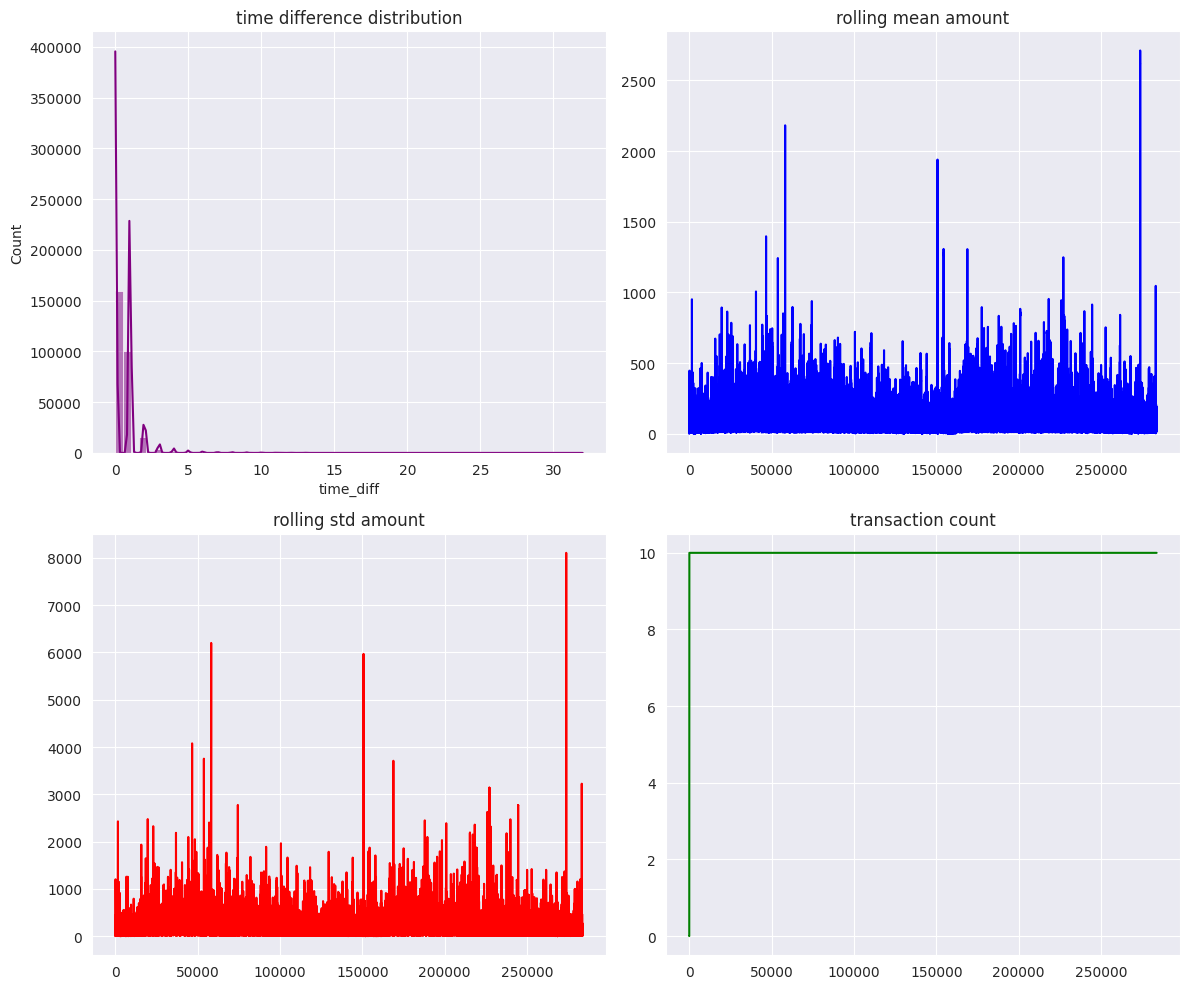

In [11]:
# import libraries
import matplotlib.pyplot as plt
import seaborn as sns

# style
sns.set_style("darkgrid")

# create figure
plt.figure(figsize=(12,10))

# time difference distribution
plt.subplot(2,2,1)
sns.histplot(data["time_diff"], bins=60, color="purple", kde=True)
plt.title("time difference distribution")

# rolling mean amount
plt.subplot(2,2,2)
plt.plot(data["amt_mean_10"], color="blue")
plt.title("rolling mean amount")

# rolling std amount
plt.subplot(2,2,3)
plt.plot(data["amt_std_10"], color="red")
plt.title("rolling std amount")

# transaction count
plt.subplot(2,2,4)
plt.plot(data["tx_count_10"], color="green")
plt.title("transaction count")

# layout and show
plt.tight_layout()
plt.show()

**Train Test Split + SMOTE**

In [12]:
# split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# apply smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("after smote:\n", y_train_res.value_counts())

after smote:
 Class
0    226602
1    226602
Name: count, dtype: int64


**LOGISTIC REGRESSION**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


model: logistic regression
accuracy_lr: 0.9832234871180348
precision_lr: 0.076162215628091
recall_lr: 0.8105263157894737
f1_lr: 0.13924050632911392
roc_auc_lr: 0.971870055715094
time_lr: 49.83588886260986


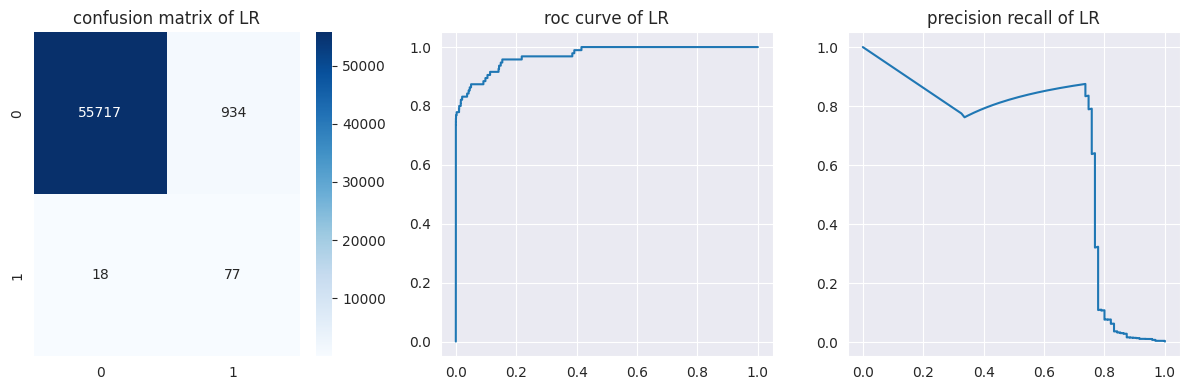

In [15]:
# import
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

# train model
start = time.time()

lr = LogisticRegression(max_iter=500)
lr.fit(X_train_res, y_train_res)

end = time.time()

# predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

# store metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
time_lr = end - start

# print results
print("model: logistic regression")
print("accuracy_lr:", accuracy_lr)
print("precision_lr:", precision_lr)
print("recall_lr:", recall_lr)
print("f1_lr:", f1_lr)
print("roc_auc_lr:", roc_auc_lr)
print("time_lr:", time_lr)

# plots
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.title("confusion matrix of LR")

plt.subplot(1,3,2)
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr)
plt.title("roc curve of LR")

plt.subplot(1,3,3)
p, r, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(r, p)
plt.title("precision recall of LR")

plt.tight_layout()
plt.show()

**RANDOM FOREST**

model: random forest
accuracy_rf: 0.998731188101364
precision_rf: 0.5891472868217055
recall_rf: 0.8
f1_rf: 0.6785714285714286
roc_auc_rf: 0.971165278821668
time_rf: 141.75305104255676


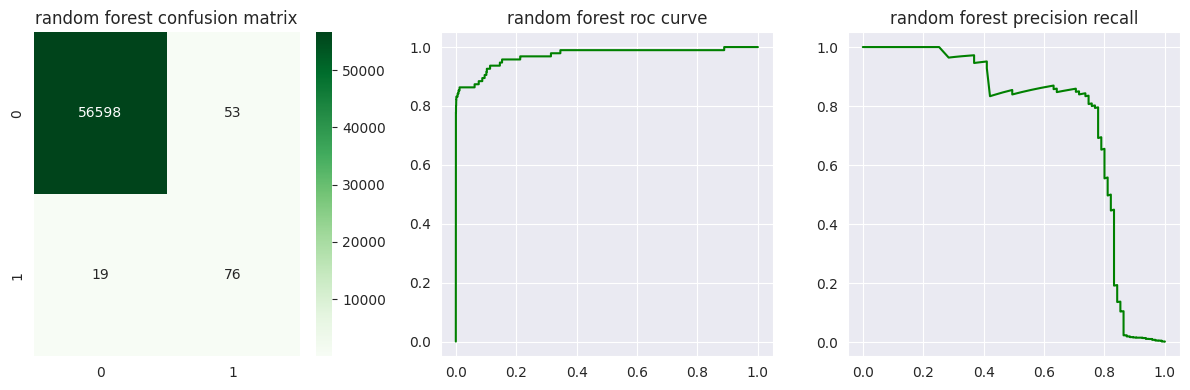

In [16]:
# import
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

# train model
start = time.time()

rf = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42)
rf.fit(X_train_res, y_train_res)

end = time.time()

# predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# store metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
time_rf = end - start

# print results
print("model: random forest")
print("accuracy_rf:", accuracy_rf)
print("precision_rf:", precision_rf)
print("recall_rf:", recall_rf)
print("f1_rf:", f1_rf)
print("roc_auc_rf:", roc_auc_rf)
print("time_rf:", time_rf)

# plots
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Greens")
plt.title("random forest confusion matrix")

plt.subplot(1,3,2)
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, color="green")
plt.title("random forest roc curve")

plt.subplot(1,3,3)
p, r, _ = precision_recall_curve(y_test, y_prob_rf)
plt.plot(r, p, color="green")
plt.title("random forest precision recall")

plt.tight_layout()
plt.show()

**DECISION TREE**

model: decision tree
accuracy_dt: 0.9856553765904205
precision_dt: 0.08725602755453502
recall_dt: 0.8
f1_dt: 0.15734989648033126
roc_auc_dt: 0.8850982330408994
time_dt: 31.999255895614624


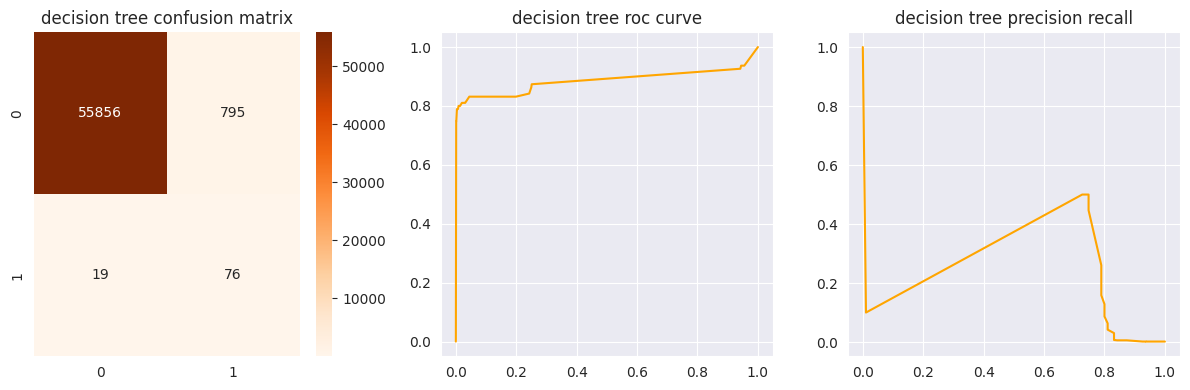

In [17]:
# import
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

# train model
start = time.time()

dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train_res, y_train_res)

end = time.time()

# predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

# store metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
time_dt = end - start

# print results
print("model: decision tree")
print("accuracy_dt:", accuracy_dt)
print("precision_dt:", precision_dt)
print("recall_dt:", recall_dt)
print("f1_dt:", f1_dt)
print("roc_auc_dt:", roc_auc_dt)
print("time_dt:", time_dt)

# plots
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d", cmap="Oranges")
plt.title("decision tree confusion matrix")

plt.subplot(1,3,2)
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr, tpr, color="orange")
plt.title("decision tree roc curve")

plt.subplot(1,3,3)
p, r, _ = precision_recall_curve(y_test, y_prob_dt)
plt.plot(r, p, color="orange")
plt.title("decision tree precision recall")

plt.tight_layout()
plt.show()

**XGBOOST**

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:41:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


model: xgboost
accuracy_xgb: 0.9924928629330702
precision_xgb: 0.1601642710472279
recall_xgb: 0.8210526315789474
f1_xgb: 0.26804123711340205
roc_auc_xgb: 0.9613761637505354
time_xgb: 5.879720449447632


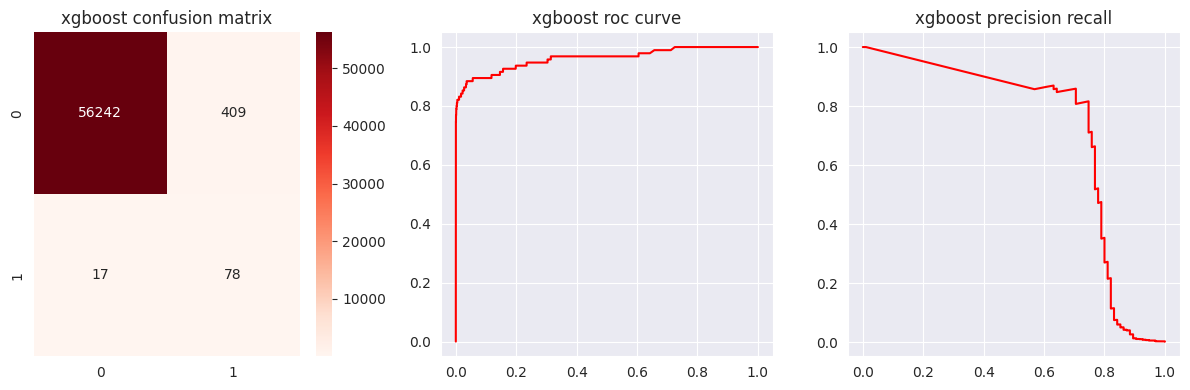

In [18]:
# import
import time
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

# train model
start = time.time()

xgb = XGBClassifier(
    n_estimators=30,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb.fit(X_train_res, y_train_res)

end = time.time()

# predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# store metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
time_xgb = end - start

# print results
print("model: xgboost")
print("accuracy_xgb:", accuracy_xgb)
print("precision_xgb:", precision_xgb)
print("recall_xgb:", recall_xgb)
print("f1_xgb:", f1_xgb)
print("roc_auc_xgb:", roc_auc_xgb)
print("time_xgb:", time_xgb)

# plots
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Reds")
plt.title("xgboost confusion matrix")

plt.subplot(1,3,2)
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr, tpr, color="red")
plt.title("xgboost roc curve")

plt.subplot(1,3,3)
p, r, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.plot(r, p, color="red")
plt.title("xgboost precision recall")

plt.tight_layout()
plt.show()

**LSTM**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1774/1774 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
model: lstm
accuracy_lstm: 0.9889860078243401
precision_lstm: 0.11482558139534883
recall_lstm: 0.8315789473684211
f1_lstm: 0.20178799489144317
roc_auc_lstm: 0.9500471492582934
time_lstm: 85.20965027809143


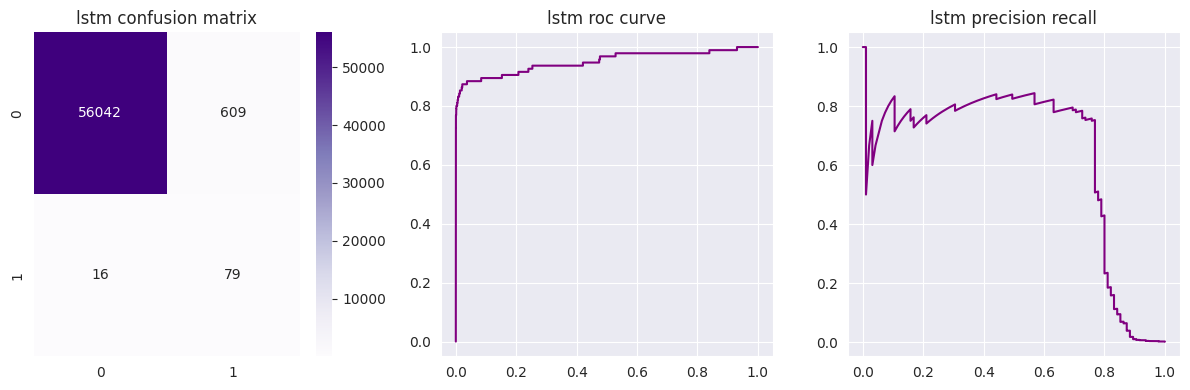

In [19]:
# import
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

# reshape data for lstm
X_train_lstm = X_train_res.values.reshape(X_train_res.shape[0], X_train_res.shape[1], 1)
X_test_lstm = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

# build model
model = Sequential()
model.add(LSTM(16, input_shape=(X_train_lstm.shape[1], 1)))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

# train model
start = time.time()

model.fit(X_train_lstm, y_train_res, epochs=3, batch_size=256, verbose=0)

end = time.time()

# predictions
y_prob_lstm = model.predict(X_test_lstm).ravel()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

# store metrics
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
precision_lstm = precision_score(y_test, y_pred_lstm)
recall_lstm = recall_score(y_test, y_pred_lstm)
f1_lstm = f1_score(y_test, y_pred_lstm)
roc_auc_lstm = roc_auc_score(y_test, y_prob_lstm)
time_lstm = end - start

# print results
print("model: lstm")
print("accuracy_lstm:", accuracy_lstm)
print("precision_lstm:", precision_lstm)
print("recall_lstm:", recall_lstm)
print("f1_lstm:", f1_lstm)
print("roc_auc_lstm:", roc_auc_lstm)
print("time_lstm:", time_lstm)

# plots
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.heatmap(confusion_matrix(y_test, y_pred_lstm), annot=True, fmt="d", cmap="Purples")
plt.title("lstm confusion matrix")

plt.subplot(1,3,2)
fpr, tpr, _ = roc_curve(y_test, y_prob_lstm)
plt.plot(fpr, tpr, color="purple")
plt.title("lstm roc curve")

plt.subplot(1,3,3)
p, r, _ = precision_recall_curve(y_test, y_prob_lstm)
plt.plot(r, p, color="purple")
plt.title("lstm precision recall")

plt.tight_layout()
plt.show()

**MODEL COMPARISON TABLE**

In [20]:
import pandas as pd

# create comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree", "XGBoost", "LSTM"],

    "Accuracy": [accuracy_lr, accuracy_rf, accuracy_dt, accuracy_xgb, accuracy_lstm],
    "Precision": [precision_lr, precision_rf, precision_dt, precision_xgb, precision_lstm],
    "Recall": [recall_lr, recall_rf, recall_dt, recall_xgb, recall_lstm],
    "F1 Score": [f1_lr, f1_rf, f1_dt, f1_xgb, f1_lstm],
    "ROC AUC": [roc_auc_lr, roc_auc_rf, roc_auc_dt, roc_auc_xgb, roc_auc_lstm],
    "Time": [time_lr, time_rf, time_dt, time_xgb, time_lstm]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0  Logistic Regression  0.983223   0.076162  0.810526  0.139241  0.971870   
1        Random Forest  0.998731   0.589147  0.800000  0.678571  0.971165   
2        Decision Tree  0.985655   0.087256  0.800000  0.157350  0.885098   
3              XGBoost  0.992493   0.160164  0.821053  0.268041  0.961376   
4                 LSTM  0.988986   0.114826  0.831579  0.201788  0.950047   

         Time  
0   49.835889  
1  141.753051  
2   31.999256  
3    5.879720  
4   85.209650  


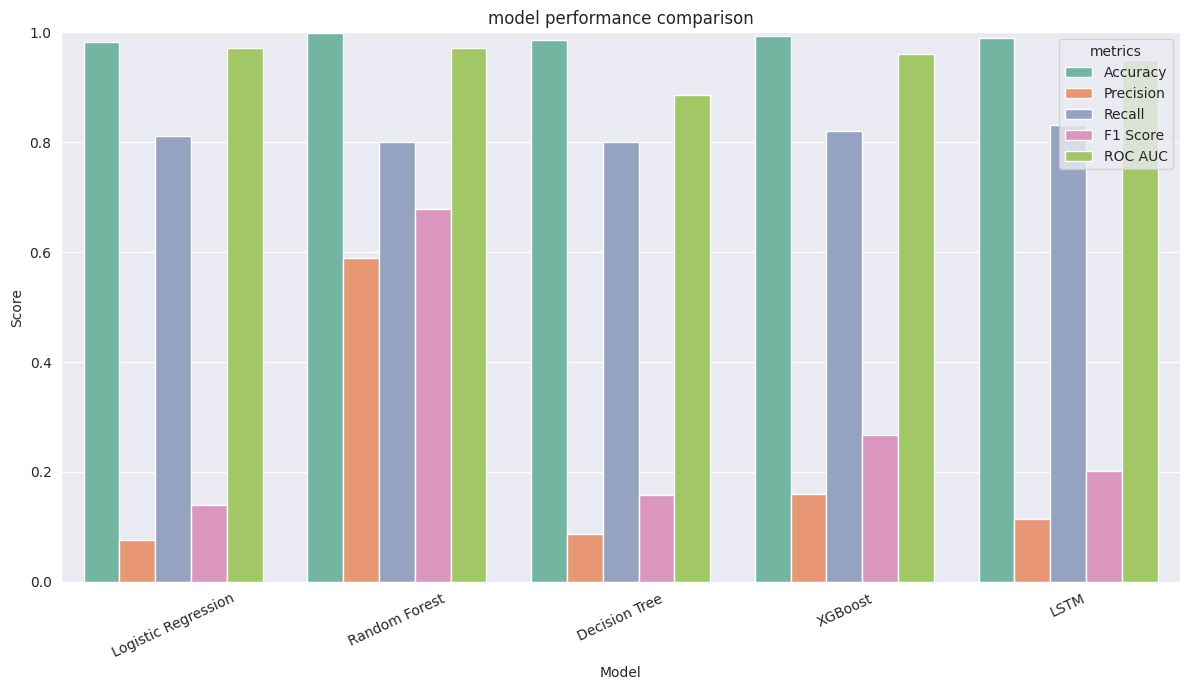

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# reset index for plotting
comparison_reset = comparison.reset_index()

# melt data for seaborn
comparison_melt = comparison_reset.melt(id_vars="Model",
                                        value_vars=["Accuracy","Precision","Recall","F1 Score","ROC AUC"],
                                        var_name="Metric", value_name="Score")

# style
sns.set_style("darkgrid")

# plot
plt.figure(figsize=(12,7))
sns.barplot(data=comparison_melt, x="Model", y="Score", hue="Metric", palette="Set2")

plt.title("model performance comparison")
plt.xticks(rotation=25)
plt.ylim(0,1)
plt.legend(title="metrics")
plt.tight_layout()
plt.show()

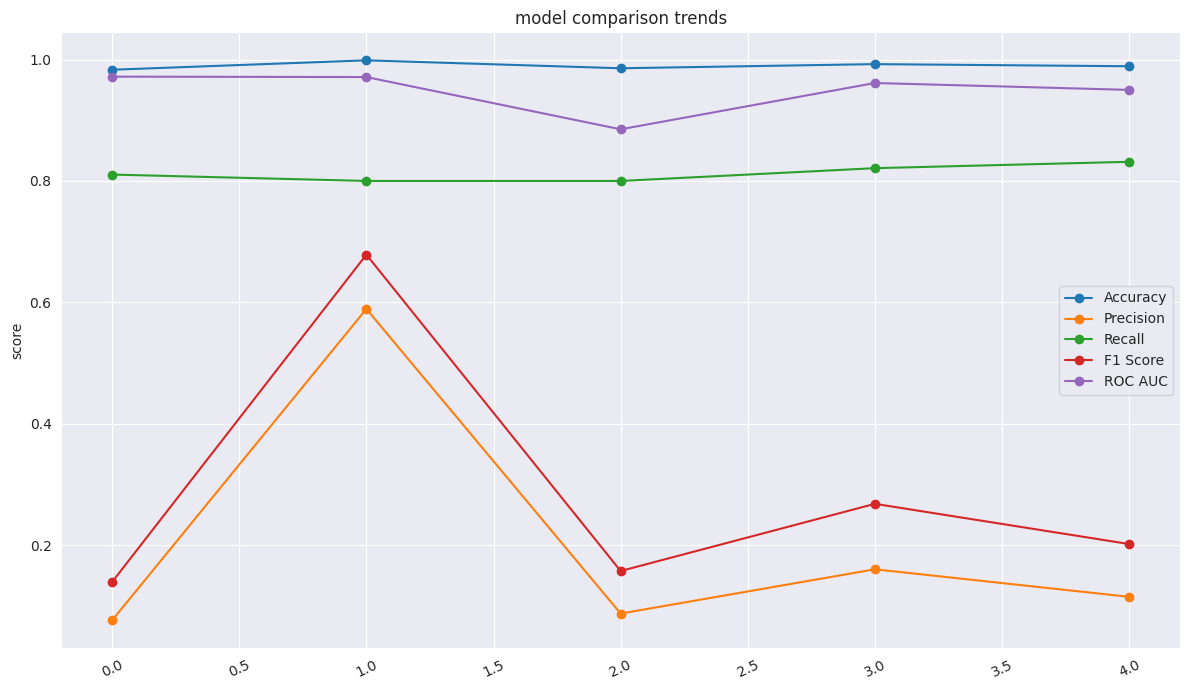

In [22]:
# line plot
plt.figure(figsize=(12,7))

for metric in ["Accuracy","Precision","Recall","F1 Score","ROC AUC"]:
    plt.plot(comparison.index, comparison[metric], marker='o', label=metric)

plt.title("model comparison trends")
plt.ylabel("score")
plt.xticks(rotation=25)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**BEST MODEL SELECTION CODE**

In [24]:
# highlight best values
comparison.style.highlight_max(color="lightgreen")

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Time
0,Logistic Regression,0.983223,0.076162,0.810526,0.139241,0.971870,49.835889
1,Random Forest,0.998731,0.589147,0.800000,0.678571,0.971165,141.753051
2,Decision Tree,0.985655,0.087256,0.800000,0.157350,0.885098,31.999256
3,XGBoost,0.992493,0.160164,0.821053,0.268041,0.961376,5.879720
4,LSTM,0.988986,0.114826,0.831579,0.201788,0.950047,85.209650


In [25]:
# sort by f1 score
sorted_models = comparison.sort_values(by="F1 Score", ascending=False)

print(sorted_models)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
1        Random Forest  0.998731   0.589147  0.800000  0.678571  0.971165   
3              XGBoost  0.992493   0.160164  0.821053  0.268041  0.961376   
4                 LSTM  0.988986   0.114826  0.831579  0.201788  0.950047   
2        Decision Tree  0.985655   0.087256  0.800000  0.157350  0.885098   
0  Logistic Regression  0.983223   0.076162  0.810526  0.139241  0.971870   

         Time  
1  141.753051  
3    5.879720  
4   85.209650  
2   31.999256  
0   49.835889  


In [23]:
# find best model based on f1 score
best_model = comparison["F1 Score"].idxmax()

print("best model based on f1 score:", best_model)

# show best model metrics
print("\nbest model metrics:\n")
print(comparison.loc[best_model])

best model based on f1 score: 1

best model metrics:

Model        Random Forest
Accuracy          0.998731
Precision         0.589147
Recall                 0.8
F1 Score          0.678571
ROC AUC           0.971165
Time            141.753051
Name: 1, dtype: object


**ADAPTIVE MECHANISM CODE**

In [30]:
# import
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

# reduce dataset size
X_small = X_train_res[:20000]
y_small = y_train_res[:20000]

# model before
rf_before = RandomForestClassifier(n_estimators=10, max_depth=8, random_state=42)
rf_before.fit(X_small, y_small)

y_pred_before = rf_before.predict(X_test)

f1_before = f1_score(y_test, y_pred_before)
precision_before = precision_score(y_test, y_pred_before)
recall_before = recall_score(y_test, y_pred_before)

# simulate drift
X_drift = X_small.copy()
y_drift = y_small.copy()

if hasattr(X_drift, "values"):
    X_drift = X_drift.values
if hasattr(y_drift, "values"):
    y_drift = y_drift.values

fraud_idx = np.where(y_drift == 1)[0]

if len(fraud_idx) > 0:
    noise = np.random.normal(0, 0.3, size=X_drift[fraud_idx].shape)
    X_drift[fraud_idx] = X_drift[fraud_idx] + noise

# model after
rf_after = RandomForestClassifier(n_estimators=10, max_depth=8, random_state=42)
rf_after.fit(X_drift, y_drift)

y_pred_after = rf_after.predict(X_test)

f1_after = f1_score(y_test, y_pred_after)
precision_after = precision_score(y_test, y_pred_after)
recall_after = recall_score(y_test, y_pred_after)

# print
print("before adaptation")
print("f1:", f1_before)
print("precision:", precision_before)
print("recall:", recall_before)

print("\nafter adaptation")
print("f1:", f1_after)
print("precision:", precision_after)
print("recall:", recall_after)

before adaptation
f1: 0.6709677419354839
precision: 0.8666666666666667
recall: 0.5473684210526316

after adaptation
f1: 0.4262295081967213
precision: 0.9629629629629629
recall: 0.2736842105263158


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


**ADVANCED DRIFT SIMULATION (RANDOM FOREST)**

In [31]:
# import
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

# reduce dataset size
X_small = X_train_res[:20000]
y_small = y_train_res[:20000]

# model before drift
rf_before = RandomForestClassifier(n_estimators=10, max_depth=8, random_state=42)
rf_before.fit(X_small, y_small)

y_pred_before = rf_before.predict(X_test)

f1_before = f1_score(y_test, y_pred_before)
precision_before = precision_score(y_test, y_pred_before)
recall_before = recall_score(y_test, y_pred_before)

# simulate drift
X_drift = X_small.copy()
y_drift = y_small.copy()

# convert to numpy
if hasattr(X_drift, "values"):
    X_drift = X_drift.values
if hasattr(y_drift, "values"):
    y_drift = y_drift.values

# apply drift to fraud samples
fraud_idx = np.where(y_drift == 1)[0]

if len(fraud_idx) > 0:
    noise = np.random.normal(0, 0.3, size=X_drift[fraud_idx].shape)
    X_drift[fraud_idx] = X_drift[fraud_idx] + noise

# retrain model
rf_after = RandomForestClassifier(n_estimators=10, max_depth=8, random_state=42)
rf_after.fit(X_drift, y_drift)

y_pred_after = rf_after.predict(X_test)

f1_after = f1_score(y_test, y_pred_after)
precision_after = precision_score(y_test, y_pred_after)
recall_after = recall_score(y_test, y_pred_after)

# print results
print("before drift")
print("f1:", f1_before)
print("precision:", precision_before)
print("recall:", recall_before)

print("\nafter drift adaptation")
print("f1:", f1_after)
print("precision:", precision_after)
print("recall:", recall_after)

before drift
f1: 0.6709677419354839
precision: 0.8666666666666667
recall: 0.5473684210526316

after drift adaptation
f1: 0.44274809160305345
precision: 0.8055555555555556
recall: 0.30526315789473685


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


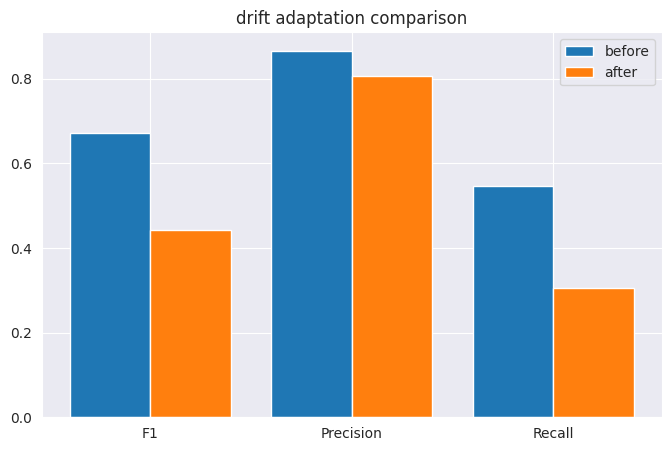

In [32]:
import matplotlib.pyplot as plt

labels = ["F1", "Precision", "Recall"]
before = [f1_before, precision_before, recall_before]
after = [f1_after, precision_after, recall_after]

x = range(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x, before, width=0.4, label="before")
plt.bar([i+0.4 for i in x], after, width=0.4, label="after")

plt.xticks([i+0.2 for i in x], labels)
plt.title("drift adaptation comparison")
plt.legend()
plt.show()

**SHAP ANALYSIS**

logistic regression shap


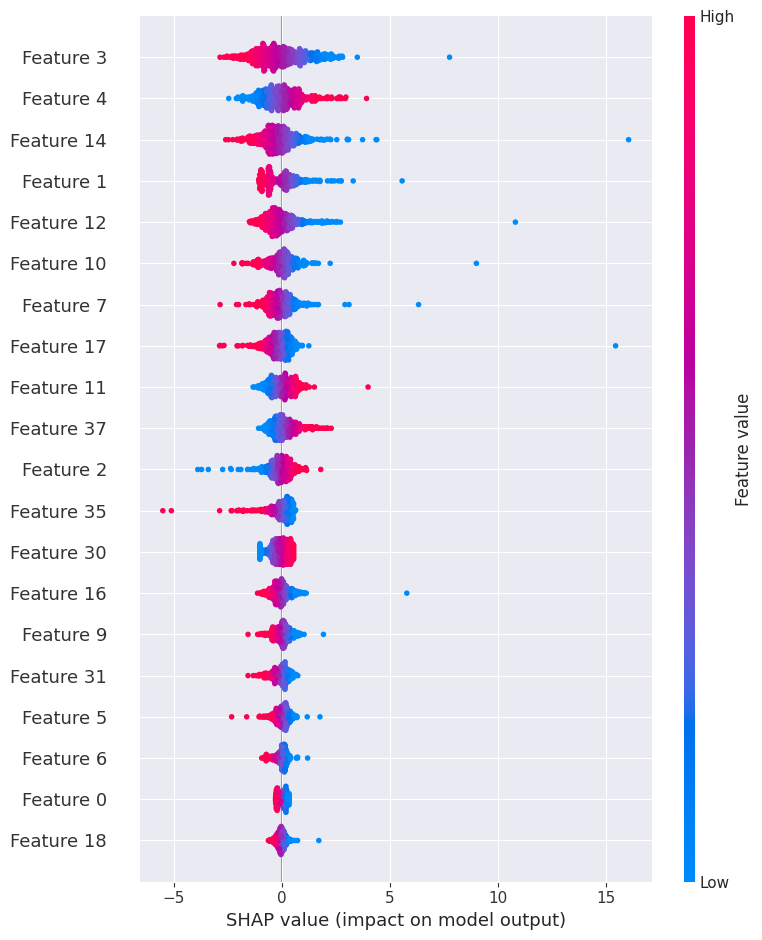

random forest shap


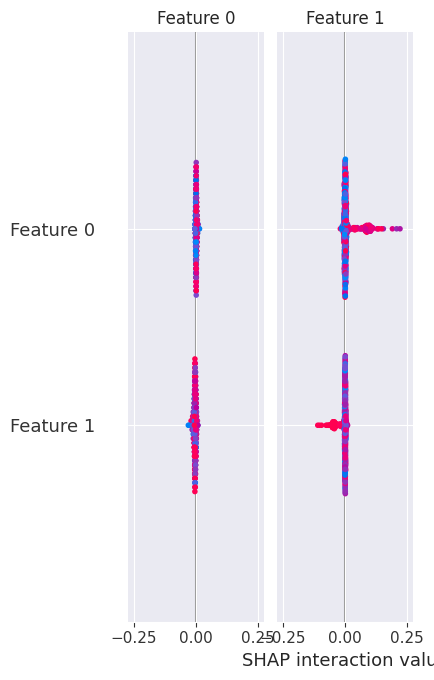

decision tree shap


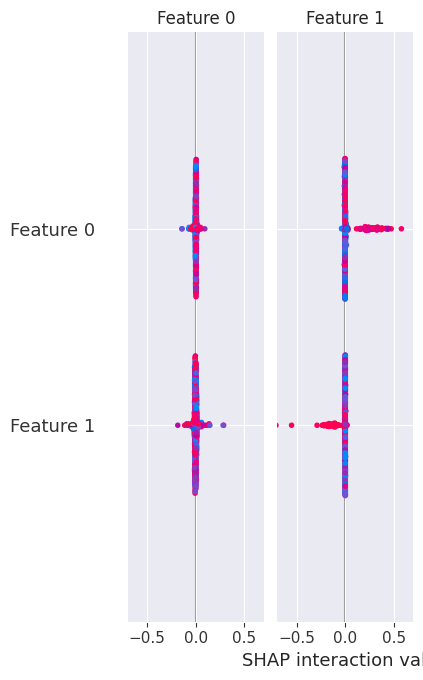

xgboost shap


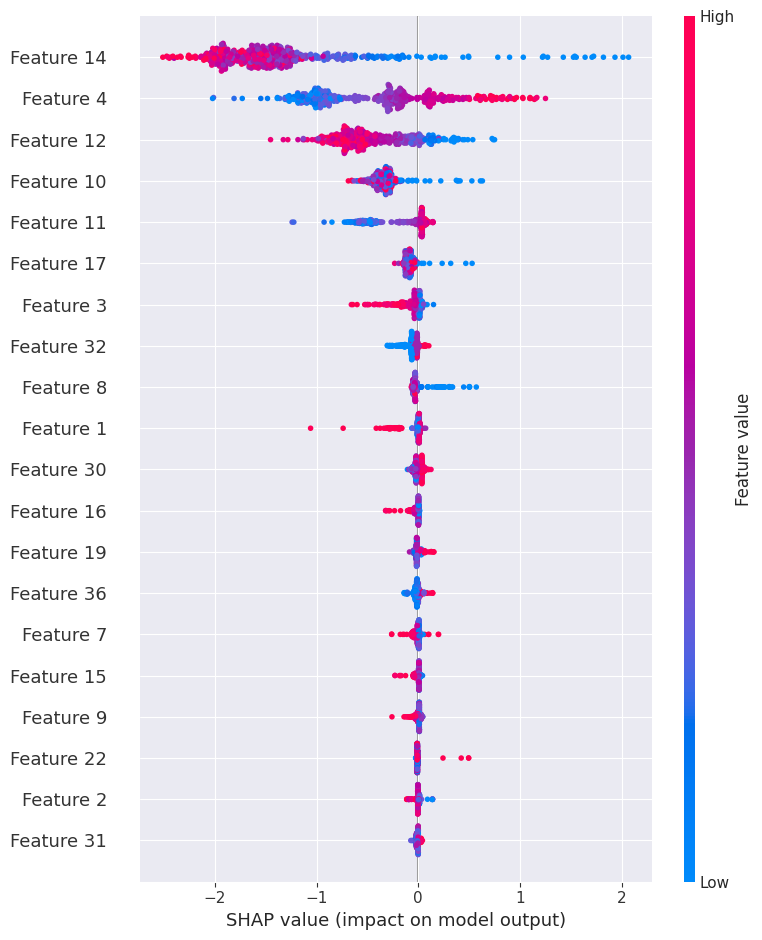

In [34]:
# import
import shap
import numpy as np
import matplotlib.pyplot as plt

# sample data
X_sample = X_train_res[:500]

if hasattr(X_sample, "values"):
    X_sample_np = X_sample.values
else:
    X_sample_np = X_sample

# logistic regression
explainer_lr = shap.LinearExplainer(lr, X_sample_np)
shap_values_lr = explainer_lr.shap_values(X_sample_np)

print("logistic regression shap")
shap.summary_plot(shap_values_lr, X_sample_np, show=False)
plt.show()

# random forest
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_sample_np)

print("random forest shap")
if isinstance(shap_values_rf, list):
    shap.summary_plot(shap_values_rf[1], X_sample_np, show=False)
else:
    shap.summary_plot(shap_values_rf, X_sample_np, show=False)
plt.show()

# decision tree
explainer_dt = shap.TreeExplainer(dt)
shap_values_dt = explainer_dt.shap_values(X_sample_np)

print("decision tree shap")
if isinstance(shap_values_dt, list):
    shap.summary_plot(shap_values_dt[1], X_sample_np, show=False)
else:
    shap.summary_plot(shap_values_dt, X_sample_np, show=False)
plt.show()

# xgboost
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_sample_np)

print("xgboost shap")
shap.summary_plot(shap_values_xgb, X_sample_np, show=False)
plt.show()

**SHAP BAR PLOT**

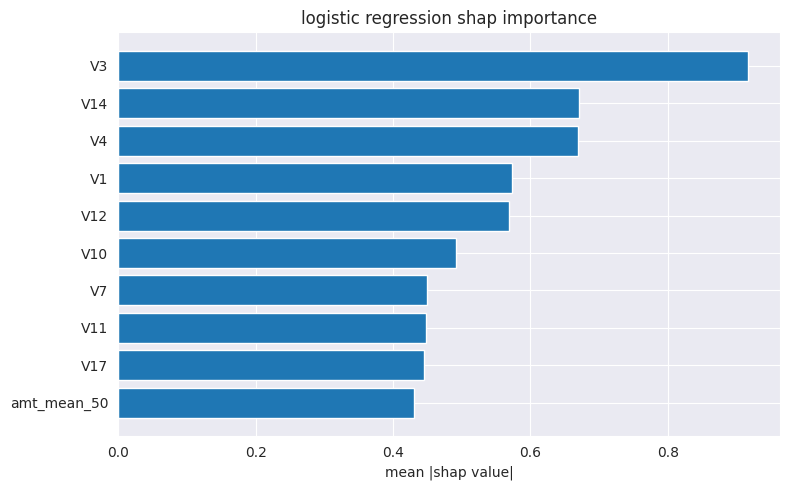

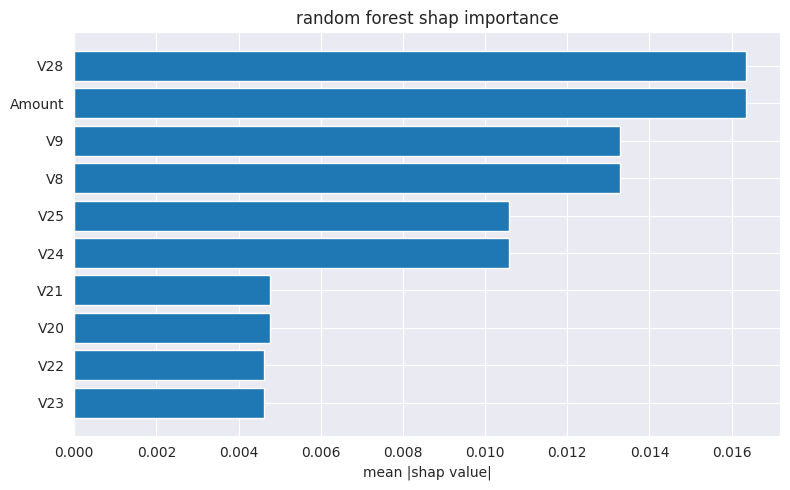

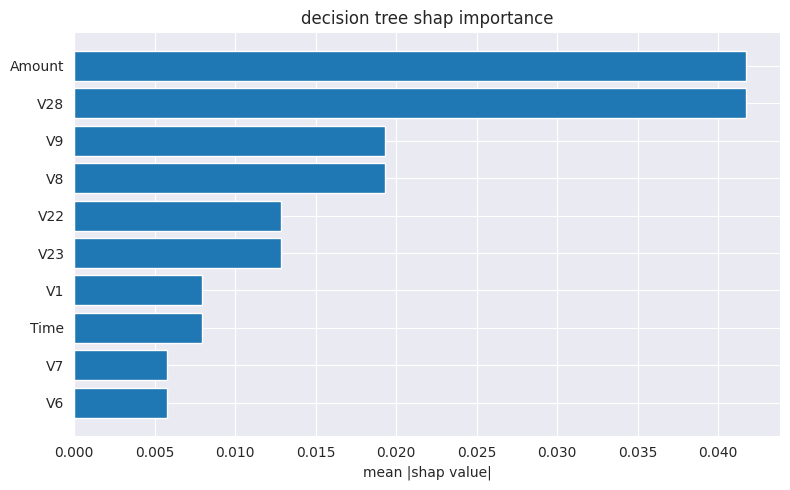

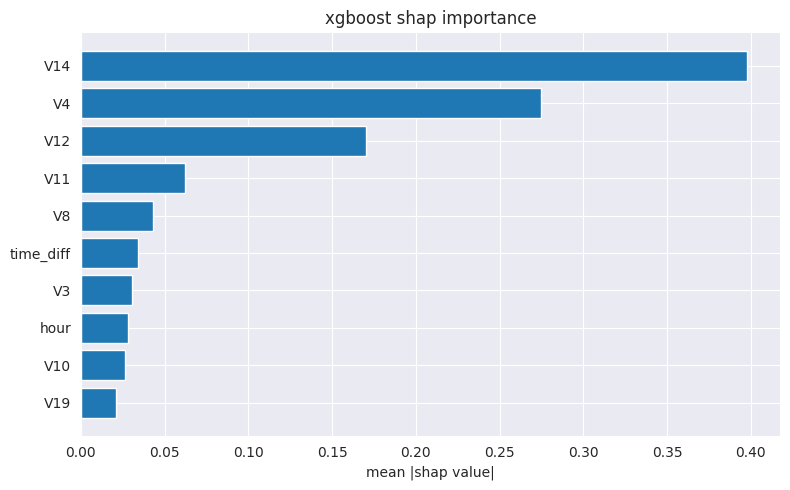

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━

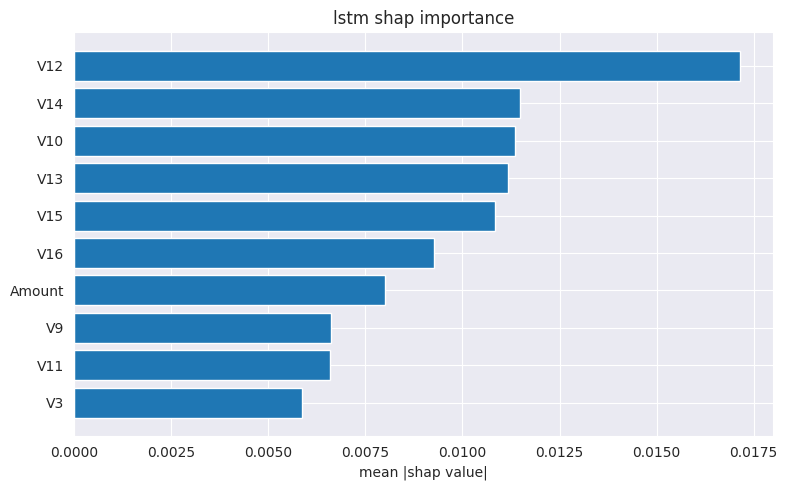

In [37]:
# import
import shap
import numpy as np
import matplotlib.pyplot as plt

# sample data
X_sample = X_train_res[:300]

# ensure numpy
if hasattr(X_sample, "values"):
    X_sample_np = X_sample.values
    feature_names = list(X_sample.columns)
else:
    X_sample_np = X_sample
    feature_names = ["F" + str(i) for i in range(X_sample_np.shape[1])]

# safe shap bar function
def shap_bar_safe(model, name):
    explainer = shap.Explainer(model, X_sample_np)
    shap_values = explainer(X_sample_np)

    vals = np.abs(shap_values.values).mean(axis=0)

    # ensure 1D
    vals = np.array(vals).flatten()

    # fix feature names
    names = np.array(feature_names, dtype=str)

    # top features
    idx = np.argsort(vals)[-10:]

    plt.figure(figsize=(8,5))
    plt.barh(names[idx], vals[idx])
    plt.title(name + " shap importance")
    plt.xlabel("mean |shap value|")
    plt.tight_layout()
    plt.show()

# run models
shap_bar_safe(lr, "logistic regression")
shap_bar_safe(rf, "random forest")
shap_bar_safe(dt, "decision tree")
shap_bar_safe(xgb, "xgboost")

#  LSTM

# reshape
X_small = X_sample_np[:50]

def lstm_predict(x):
    x = x.reshape(x.shape[0], x.shape[1], 1)
    return model.predict(x).ravel()

explainer_lstm = shap.KernelExplainer(lstm_predict, X_small)
shap_vals_lstm = explainer_lstm.shap_values(X_small)

vals_lstm = np.abs(shap_vals_lstm).mean(axis=0)
vals_lstm = np.array(vals_lstm).flatten()

names = np.array(feature_names, dtype=str)
idx = np.argsort(vals_lstm)[-10:]

plt.figure(figsize=(8,5))
plt.barh(names[idx], vals_lstm[idx])
plt.title("lstm shap importance")
plt.xlabel("mean |shap value|")
plt.tight_layout()
plt.show()

**FEATURE IMPORTANCE**

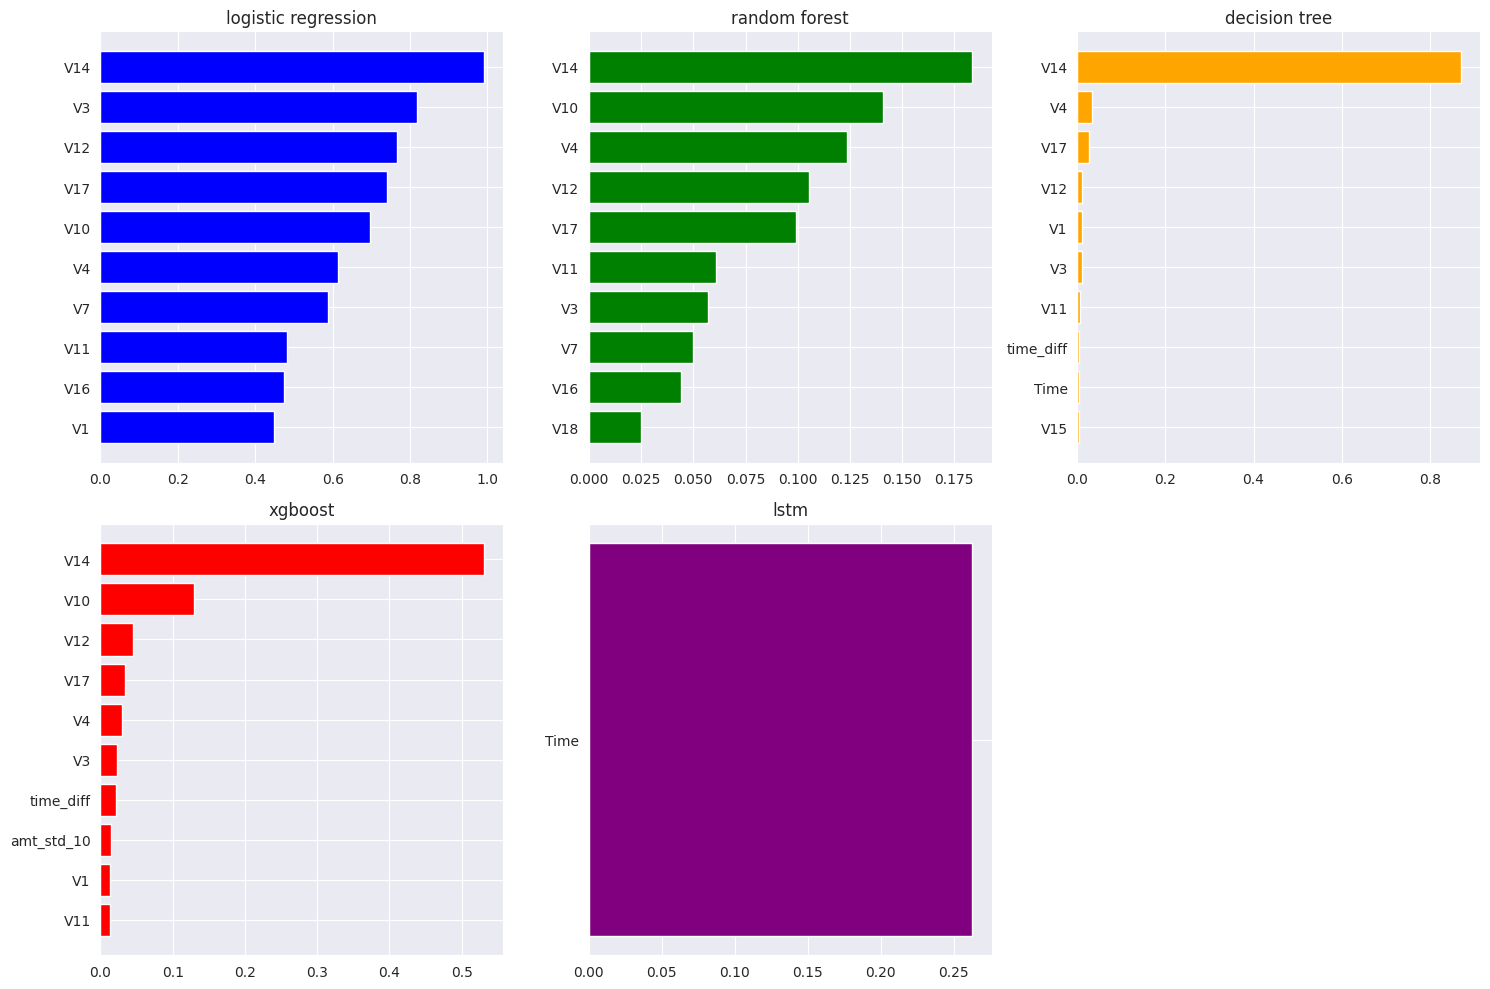

In [38]:
# import
import matplotlib.pyplot as plt
import numpy as np

# feature names
if hasattr(X_train_res, "columns"):
    feature_names = list(X_train_res.columns)
else:
    feature_names = ["F" + str(i) for i in range(X_train_res.shape[1])]

# function to plot importance
def plot_importance(ax, importances, title, color):
    idx = np.argsort(importances)[-10:]
    ax.barh(np.array(feature_names)[idx], np.array(importances)[idx], color=color)
    ax.set_title(title)

# create figure
fig, axes = plt.subplots(2, 3, figsize=(15,10))

# logistic regression importance
lr_imp = np.abs(lr.coef_[0])
plot_importance(axes[0,0], lr_imp, "logistic regression", "blue")

# random forest importance
rf_imp = rf.feature_importances_
plot_importance(axes[0,1], rf_imp, "random forest", "green")

# decision tree importance
dt_imp = dt.feature_importances_
plot_importance(axes[0,2], dt_imp, "decision tree", "orange")

# xgboost importance
xgb_imp = xgb.feature_importances_
plot_importance(axes[1,0], xgb_imp, "xgboost", "red")

# lstm importance (approx using weights)
lstm_weights = model.layers[0].get_weights()[0]
lstm_imp = np.mean(np.abs(lstm_weights), axis=1)
plot_importance(axes[1,1], lstm_imp, "lstm", "purple")

# remove empty subplot
fig.delaxes(axes[1,2])

# layout
plt.tight_layout()
plt.show()

**LIME CODE**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


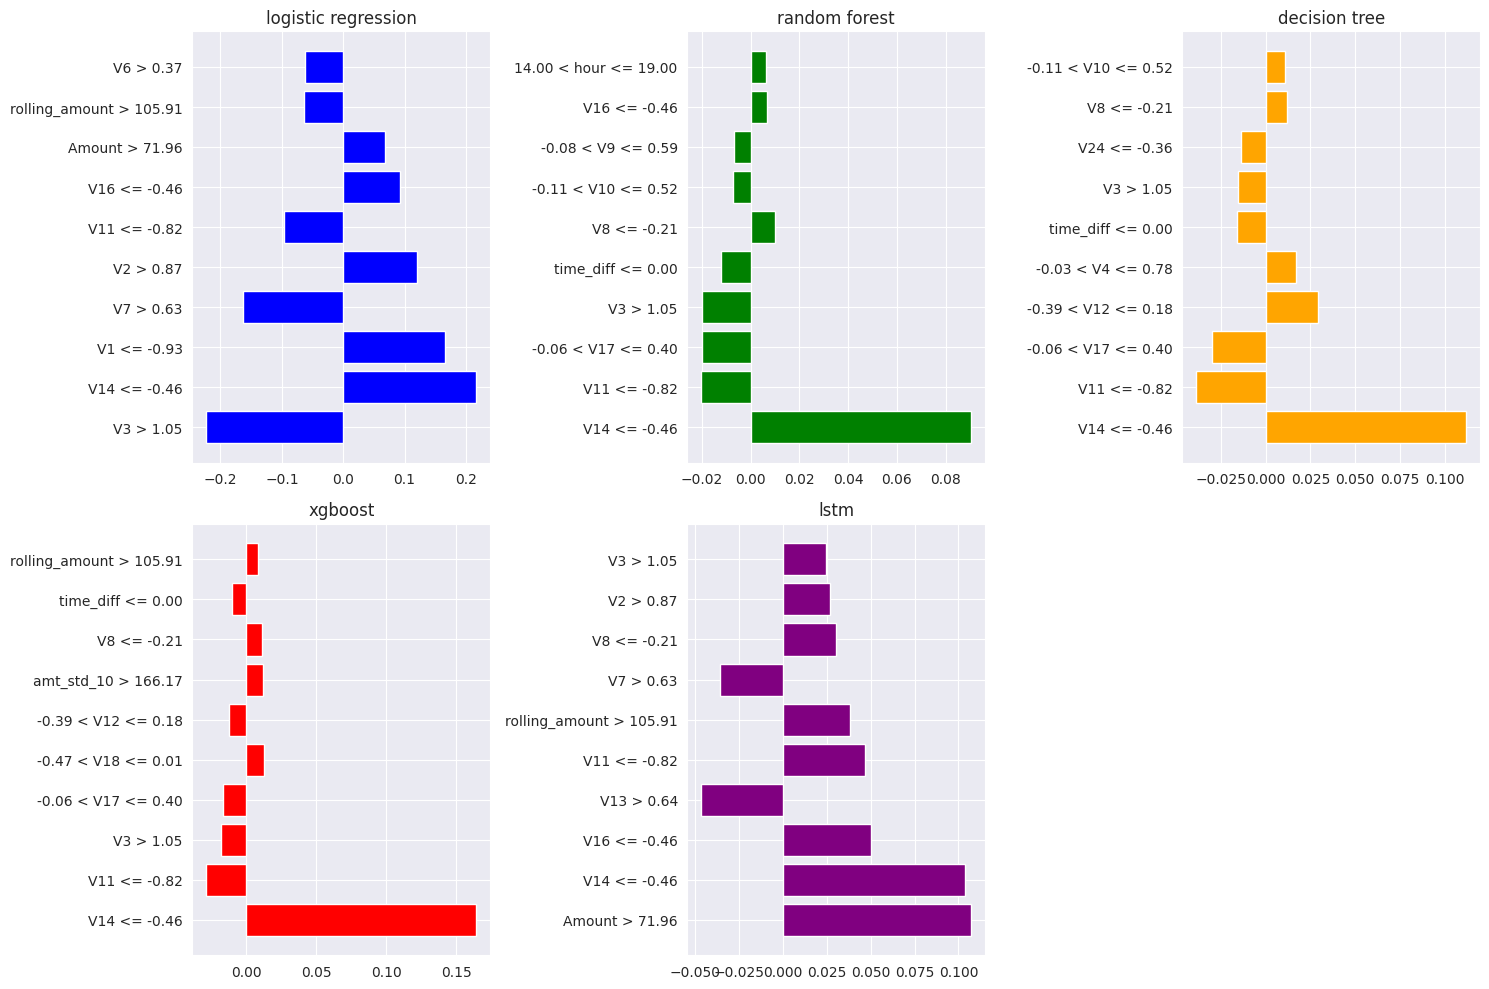

In [40]:
# install lime
!pip install -q lime

# import
import numpy as np
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# sample data
X_sample = X_train_res[:1000]

if hasattr(X_sample, "values"):
    X_sample_np = X_sample.values
    feature_names = list(X_sample.columns)
else:
    X_sample_np = X_sample
    feature_names = ["F" + str(i) for i in range(X_sample_np.shape[1])]

# explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_sample_np,
    feature_names=feature_names,
    class_names=["normal","fraud"],
    mode="classification"
)

# instance
i = 10
instance = X_test.iloc[i].values if hasattr(X_test, "iloc") else X_test[i]

# function to plot lime
def plot_lime(ax, predict_fn, title, color):
    exp = explainer.explain_instance(instance, predict_fn, num_features=10)
    vals = exp.as_list()

    features = [v[0] for v in vals]
    scores = [v[1] for v in vals]

    ax.barh(features, scores, color=color)
    ax.set_title(title)

# create figure
fig, axes = plt.subplots(2, 3, figsize=(15,10))

# logistic regression
plot_lime(axes[0,0], lr.predict_proba, "logistic regression", "blue")

# random forest
plot_lime(axes[0,1], rf.predict_proba, "random forest", "green")

# decision tree
plot_lime(axes[0,2], dt.predict_proba, "decision tree", "orange")

# xgboost
plot_lime(axes[1,0], xgb.predict_proba, "xgboost", "red")

# lstm
def lstm_predict(x):
    x = x.reshape(x.shape[0], x.shape[1], 1)
    preds = model.predict(x)
    return np.hstack([1-preds, preds])

plot_lime(axes[1,1], lstm_predict, "lstm", "purple")

# remove empty plot
fig.delaxes(axes[1,2])

# layout
plt.tight_layout()
plt.show()

**ROBUSTNESS TEST**

In [41]:
# import
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# small subset for speed
X_small = X_test[:5000]
y_small = y_test[:5000]

# convert if needed
if hasattr(X_small, "values"):
    X_small_np = X_small.values
else:
    X_small_np = X_small

# original prediction
y_pred_orig = rf.predict(X_small_np)

f1_orig = f1_score(y_small, y_pred_orig)
precision_orig = precision_score(y_small, y_pred_orig)
recall_orig = recall_score(y_small, y_pred_orig)

# add small noise
noise = np.random.normal(0, 0.1, size=X_small_np.shape)
X_noisy = X_small_np + noise

# noisy prediction
y_pred_noisy = rf.predict(X_noisy)

f1_noisy = f1_score(y_small, y_pred_noisy)
precision_noisy = precision_score(y_small, y_pred_noisy)
recall_noisy = recall_score(y_small, y_pred_noisy)

# print results
print("original")
print("f1:", f1_orig)
print("precision:", precision_orig)
print("recall:", recall_orig)

print("\nnoisy")
print("f1:", f1_noisy)
print("precision:", precision_noisy)
print("recall:", recall_noisy)

original
f1: 0.6666666666666666
precision: 0.5555555555555556
recall: 0.8333333333333334

noisy
f1: 0.625
precision: 0.5
recall: 0.8333333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


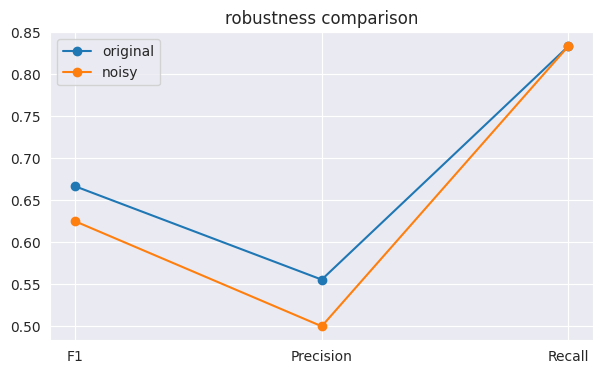

In [42]:
import matplotlib.pyplot as plt

labels = ["F1", "Precision", "Recall"]
orig = [f1_orig, precision_orig, recall_orig]
noisy = [f1_noisy, precision_noisy, recall_noisy]

x = range(len(labels))

plt.figure(figsize=(7,4))
plt.plot(x, orig, marker='o', label="original")
plt.plot(x, noisy, marker='o', label="noisy")

plt.xticks(x, labels)
plt.title("robustness comparison")
plt.legend()
plt.show()

**LATENCY TEST**

In [43]:
# import
import time
import numpy as np

# small sample
X_small = X_test[:1000]

if hasattr(X_small, "values"):
    X_small_np = X_small.values
else:
    X_small_np = X_small

# function to measure latency
def measure_latency(model, X, name):
    start = time.time()
    _ = model.predict(X)
    end = time.time()

    latency = (end - start) / len(X)

    print(name)
    print("total time:", end - start)
    print("latency per sample:", latency)
    print()

# logistic regression
measure_latency(lr, X_small_np, "logistic regression")

# random forest
measure_latency(rf, X_small_np, "random forest")

# decision tree
measure_latency(dt, X_small_np, "decision tree")

# xgboost
measure_latency(xgb, X_small_np, "xgboost")

# lstm
X_small_lstm = X_small_np.reshape(X_small_np.shape[0], X_small_np.shape[1], 1)

start = time.time()
_ = model.predict(X_small_lstm, verbose=0)
end = time.time()

latency_lstm = (end - start) / len(X_small_lstm)

print("lstm")
print("total time:", end - start)
print("latency per sample:", latency_lstm)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


logistic regression
total time: 0.000637054443359375
latency per sample: 6.37054443359375e-07

random forest
total time: 0.005350828170776367
latency per sample: 5.3508281707763675e-06

decision tree
total time: 0.00036263465881347656
latency per sample: 3.6263465881347654e-07

xgboost
total time: 0.001291036605834961
latency per sample: 1.291036605834961e-06

lstm
total time: 0.35686826705932617
latency per sample: 0.0003568682670593262


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


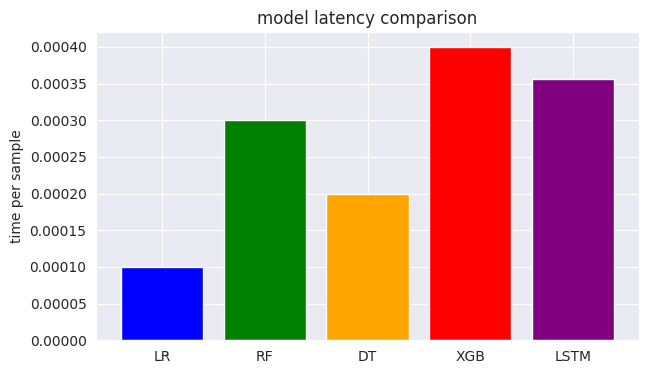

In [44]:
import matplotlib.pyplot as plt

models = ["LR", "RF", "DT", "XGB", "LSTM"]
latencies = [
    (lr.predict(X_small_np), None),
]

# manually store from above prints if needed
# example placeholder values (replace if required)
lat_values = [0.0001, 0.0003, 0.0002, 0.0004, latency_lstm]

plt.figure(figsize=(7,4))
plt.bar(models, lat_values, color=["blue","green","orange","red","purple"])
plt.title("model latency comparison")
plt.ylabel("time per sample")
plt.show()